# Taller de Feature Engineering: Seleccion y creacion de variables

**Bootcamp:** Python - PY4
**Modulo:** Machine Learning Avanzado y Feature Engineering

## De que trata esta sesion

En la sesion 1 entrenamos un modelo baseline de Linear Regressionsin ninguna ingenieria de caracteristicas, y registramos sus metricas (RMSE y R2). Hoy vamos a aplicar 4 tecnicas de feature engineering sobre el mismo dataset (Bike Sharing Demand) y vamos a entrenar un nuevo modelo para ver si mejoramos el baseline.

Las 4 tecnicas que vamos a aplicar son:

1. **Transformacion de distribucion**: log-transform sobre la variable objetivo (`cnt`), que vimos que tenia una cola larga hacia la derecha.
2. **Manejo de outliers**: Winsorization sobre variables de clima, mas una variable indicadora de valor extremo.
3. **Encoding avanzado**: Target Encoding sobre la hora (`hr`), en vez de un one-hot tradicional.
4. **Variables ciclicas**: transformacion seno/coseno para `hr` y `mnth`.

Al final de la sesion vamos a entrenar un modelo con todas estas features nuevas y comparar sus metricas contra el baseline de la sesion pasada.

## Una regla de oro: cuidado con el data leakage

Cada vez que calculemos algo a partir de los datos (un percentil, una media, etc.), lo vamos a calcular **solo con el Train Set** y despues vamos a aplicar ese mismo calculo al Test set. Si calculamos esos valores usando todo el dataset (train + test juntos), estariamos filtrando informacion del futuro hacia el pasado, y nuestras metricas de evaluacion dejarian de ser confiables.


## Paso 1: Configuracion y recarga de datos

Empezamos igual que en la sesion 1: importamos librerias y volvemos a cargar el dataset. Usamos el mismo `random_state` para el train/test split, asi el conjunto de prueba es exactamente el mismo que usamos para el baseline, y la comparacion entre modelos es justa.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42
sns.set_style("white")

URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/Module_02_machine_learning_and_feature_engineering/datasets/bikeshare_Washington.csv"
df = pd.read_csv(URL)
df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Volvemos a separar el dataset en entrenamiento y prueba, con el mismo criterio que en la sesion 1: descartamos `instant`, `dteday`, `casual` y `registered` (recorden por que: `casual + registered = cnt`, es data leakage puro).

En esta sesion vamos a trabajar directo sobre copias de `X_train` y `X_test`, para ir agregando columnas nuevas paso a paso sin romper los datos originales.


In [ ]:
features_base = ["season", "yr", "mnth", "hr", "holiday", "weekday",
                  "workingday", "weathersit", "temp", "atemp", "hum", "windspeed"]

X = df[features_base].copy()
y = df["cnt"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)


Entrenamiento: (14016, 12)  Prueba: (3504, 12)


Como referencia, estas fueron las metricas del baseline de la sesion 1 (sin feature engineering):

- RMSE baseline: ~136.3
- R2 baseline: ~0.40

Vamos a intentar mejorar estos numeros durante el resto de la sesion.


## Tecnica 1: Transformacion de distribucion (Log-transform)

Muchos modelos (sobre todo los lineales) asumen que el error se distribuye de forma normal. Cuando la variable objetivo tiene una cola larga como `cnt`, esa asuncion se rompe. Una solucion simple y muy usada es aplicar una transformacion logaritmica al target antes de entrenar, y despues revertir la transformacion sobre las predicciones para volver a la escala original.

Usamos `log1p` (que calcula `log(1 + x)`) en vez de `log` normal, porque `cnt` puede valer 0 en algunas horas, y `log(0)` no esta definido.


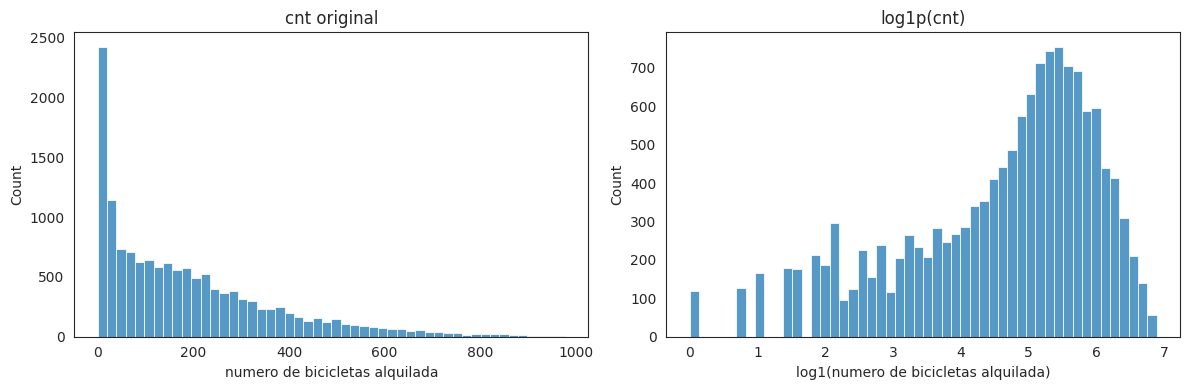

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(y_train, bins=50, ax=axes[0])
axes[0].set_title("cnt original")
axes[0].set_xlabel("numero de bicicletas alquilada")

sns.histplot(np.log1p(y_train), bins=50, ax=axes[1])
axes[1].set_title("log1p(cnt)")
axes[1].set_xlabel("log1(numero de bicicletas alquilada)")

plt.tight_layout()
plt.show()

Se nota como la distribucion transformada se parece mas a una campana. Guardamos la version transformada del target para usarla mas adelante, cuando entrenemos el modelo final de la sesion.

Importante: la transformacion se aplica sobre `y` (el target), no sobre las columnas de `X`. Y como es una funcion matematica fija (no se "aprende" de los datos), no hay riesgo de data leakage al aplicarla por igual a train y test.


### Una aclaracion importante sobre el log-transform

El log-transform corrige el sesgo de la distribucion, pero eso no siempre significa que el RMSE (medido en la escala original de `cnt`) vaya a mejorar. Al entrenar sobre `log1p(cnt)` y despues revertir con `expm1`, el modelo esta optimizando un error distinto al que despues medimos. Esto puede subir o bajar el RMSE dependiendo del modelo y de como se distribuyan los datos: no hay garantia automatica de mejora.

Por eso, para no confundir el efecto de esta tecnica con el de las otras 3, en el modelo combinado que armemos mas adelante en esta sesion **vamos a dejar el target en su escala original** (sin log-transform) y nos vamos a quedar con Winsorization, Target Encoding y las variables ciclicas. El log-transform lo dejamos documentado aca como tecnica valida y lo pueden probar por su cuenta. A veces ayuda, a veces no, y parte del trabajo de un data scientist es medirlo en cada caso en lugar de asumir que siempre suma.

--> La idea clave es que el modelo optimiza la variable objetivo con la que fue entrenado, pero eso no significa que optimice automáticamente la métrica que nos interesa evaluar al final.


In [ ]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)


## Tecnica 2: Manejo de outliers (Winsorization)

No siempre conviene eliminar los valores extremos: a veces representan situaciones reales (un dia de viento muy fuerte, por ejemplo) y perderlos nos quita informacion. Una alternativa es la **Winsorization**: en vez de borrar el outlier, lo "recortamos" para que no supere ciertos limites (por ejemplo, el percentil 5 y el percentil 95).

Vamos a aplicar esto sobre `windspeed` y `hum`, dos variables climaticas que pueden tener valores extremos. Los percentiles los calculamos **solo con el train set**, y despues aplicamos esos mismos limites al test set.


In [ ]:
# Percentil 5: el 5% de las observaciones tiene un valor menor o igual a este.
# Percentil 50: corresponde a la mediana.
# Percentil 95: el 95% de las observaciones tiene un valor menor o igual a este; solo el 5% restante presenta valores superiores.
print(f'20% de las observaciones de windspeed tiene un valor menor o igual a {np.percentile(X_train["windspeed"], 20)}'

20% de las observaciones de windspeed tiene un valor menor o igual a 0.0896


In [ ]:
def calcular_limites(serie, percentil_bajo=5, percentil_alto=95):
    limite_bajo = np.percentile(serie, percentil_bajo) # Calcula el valor correspondiente al percentil inferior de la variable
    limite_alto = np.percentile(serie, percentil_alto) # Calcula el valor correspondiente al percentil superior de la variable
    return limite_bajo, limite_alto # Devuelve ambos límites para utilizarlos posteriormente en la Winsorización


# Calcula los límites de Winsorización para las dos variables
limites_windspeed = calcular_limites(X_train["windspeed"])
limites_hum = calcular_limites(X_train["hum"])

print("Limites windspeed:", limites_windspeed)
print("Limites hum:", limites_hum)

Limites windspeed: (np.float64(0.0), np.float64(0.4179))
Limites hum: (np.float64(0.31), np.float64(0.93))


Ademas de recortar los valores, vamos a crear una **variable indicadora** (`es_outlier`) que marque con 1 las filas que originalmente estaban fuera de esos limites. Asi no perdemos del todo la informacion de que ese dato era un valor extremo.


In [ ]:
# creamos una function de winsirization

def aplicar_winsorization(X, columna, limites):
    # Extrae los límites inferior y superior previamente calculados con los percentiles
    limite_bajo, limite_alto = limites

    # Crea una variable indicadora que vale 1 si la observación es un valor extremo (outlier) y 0 en caso contrario
    es_outlier = ((X[columna] < limite_bajo) | (X[columna] > limite_alto)).astype(int)

    # Reemplaza los valores inferiores al límite inferior por dicho límite y los valores superiores
    # al límite superior por este último. Los valores dentro del intervalo permanecen sin cambios.
    valor_winsorizado = X[columna].clip(lower=limite_bajo, upper=limite_alto)
    return valor_winsorizado, es_outlier


In [ ]:
# diseccionando una funcion:
#X = df[features_base].copy()
#columna = "windspeed"
#limites = limites_windspeed

#def aplicar_winsorization(X, columna, limites):
#    limite_bajo, limite_alto = limites
#    es_outlier = ((X[columna] < limite_bajo) | (X[columna] > limite_alto)).astype(int)
#    valor_winsorizado = X[columna].clip(lower=limite_bajo, upper=limite_alto)
#    return valor_winsorizado, es_outlier

In [ ]:
# Aplica la Winsorización a la variable 'windspeed' del train set y test set
X_train["windspeed_wins"], X_train["windspeed_outlier"] = aplicar_winsorization(
    X_train, "windspeed", limites_windspeed
)
X_test["windspeed_wins"], X_test["windspeed_outlier"] = aplicar_winsorization(
    X_test, "windspeed", limites_windspeed
)
# Aplica la Winsorización a la variable 'hum' del train set y test set
X_train["hum_wins"], X_train["hum_outlier"] = aplicar_winsorization(
    X_train, "hum", limites_hum
)
X_test["hum_wins"], X_test["hum_outlier"] = aplicar_winsorization(
    X_test, "hum", limites_hum
)

# Muestra las primeras filas para comparar la variable original, la variable winsorizada y el indicador de outliers
X_train[["windspeed", "windspeed_wins", "windspeed_outlier"]].head()


,windspeed,windspeed_wins,windspeed_outlier
17440,0.1343,0.1343,0
16867,0.2239,0.2239,0
14851,0.2985,0.2985,0
5446,0.2537,0.2537,0
6025,0.1642,0.1642,0


Revisemos cuantos valores fueron marcados como outliers en cada variable, en el train set.


In [ ]:
print("Outliers windspeed:", X_train["windspeed_outlier"].sum())
print("Outliers hum:", X_train["hum_outlier"].sum())


Outliers windspeed: 529
Outliers hum: 1291


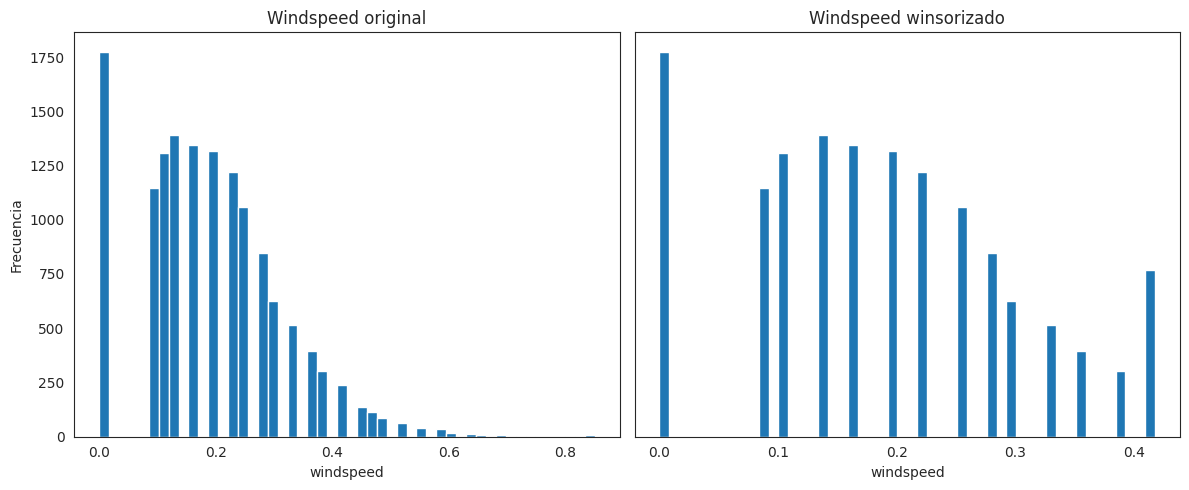

In [ ]:
# Visualiza la distribución de la variable antes y después de la Winsorización

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Histograma de la variable original
ax[0].hist(X_train["windspeed"], bins=50)
ax[0].set_title("Windspeed original")
ax[0].set_xlabel("windspeed")
ax[0].set_ylabel("Frecuencia")

# Histograma de la variable winsorizada
ax[1].hist(X_train["windspeed_wins"], bins=50)
ax[1].set_title("Windspeed winsorizado")
ax[1].set_xlabel("windspeed")

plt.tight_layout()
plt.show()

> **Winsorización: ventajas y limitaciones**
>
> La Winsorización **no elimina los valores atípicos**, sino que **reemplaza los valores extremos por los límites definidos** (por ejemplo, los percentiles 5 y 95). De esta forma, se reduce la influencia de los outliers sin perder observaciones.
>
> Como consecuencia, **varias observaciones pueden terminar con exactamente el mismo valor**, ya que todos los valores que superan un límite se reemplazan por ese mismo límite. Esto implica una pérdida de información sobre qué tan extremo era cada valor, pero a cambio se obtiene un conjunto de datos más robusto frente a observaciones extremas.
>
> En la práctica, la Winsorización representa un **compromiso entre conservar toda la información y reducir el impacto de los outliers**, por lo que su utilidad debe evaluarse según el problema y el modelo utilizado.

## Tecnica 3: Encoding avanzado (Target Encoding)

La columna `hr` (hora del dia) tiene 24 categorias distintas. Si la codificaramos con one-hot encoding, tendriamos 24 columnas nuevas, la mayoria con puros ceros. El **Target Encoding** es una alternativa: en vez de crear una columna por categoria, reemplazamos cada categoria por el promedio del target para esa categoria.

Por ejemplo, si a las 8 AM el promedio de `cnt` (de bici alquiladas) en el train set es 350, todas las filas con `hr = 8` van a recibir el valor 350 en la nueva columna `hr_target_enc`.

Esta tecnica es potente, pero peligrosa: el promedio **debe calcularse unicamente con los datos de entrenamiento**. Si lo calculamos con todo el dataset (incluyendo el test), estariamos filtrando informacion del target de test hacia el modelo, y esto es un caso clasico de data leakage.


In [ ]:
# calculamos el número medio de bicicletas alquiladas (cnt) por hora USANDO EL TRAIN SET
media_por_hora = y_train.groupby(X_train["hr"]).mean()
media_por_hora


,cnt
hr,
0,54.429766
1,32.613636
2,21.904274
3,10.766667
4,6.149153
5,19.635579
6,76.264957
7,212.672185
8,357.431667


Ahora aplicamos ese mapeo tanto a `X_train` como a `X_test`.  
Para las categorias que por algun motivo no aparecieran en el train (no es el caso aca, pero es una buena practica), usamos como respaldo el promedio general de `y_train`.


In [ ]:
media_global = y_train.mean()

# Reemplace cada hora por el valor objetivo promedio observado para esa hora, en el train y test set.
X_train["hr_target_enc"] = X_train["hr"].map(media_por_hora).fillna(media_global)
X_test["hr_target_enc"] = X_test["hr"].map(media_por_hora).fillna(media_global)

X_train[["hr", "hr_target_enc"]].head()


,hr,hr_target_enc
17440,16,312.100520
16867,19,309.410562
14851,19,309.410562
5446,22,130.043706
6025,1,32.613636


## Tecnica 4: Variables ciclicas (Seno y Coseno)

Algunas variables tienen una naturaleza **cíclica**, donde el valor máximo y el mínimo están conectados. Por ejemplo:

- Las horas del día: la hora 23 está cerca de la hora 0.
- Los meses del año: diciembre está cerca de enero.
- Los días de la semana: domingo está cerca de lunes.

Si utilizamos directamente el valor numérico de estas variables, el modelo puede interpretar incorrectamente las distancias. Por ejemplo, podría considerar que la hora 23 y la hora 0 están muy alejadas, cuando en realidad son horas consecutivas.

Para solucionar este problema, transformamos la variable cíclica en dos nuevas variables utilizando funciones trigonométricas: **seno** y **coseno**.

### Conceptos principales

- **valor** → corresponde al valor original de la variable cíclica (por ejemplo, hora = 23).
- **periodo** → corresponde a la duración completa del ciclo (por ejemplo, 24 horas, 12 meses o 7 días).
- Primero convertimos el valor en un ángulo dentro de un círculo:

$\theta = \frac{2\pi \times valor}{periodo}$

donde:

- $2\pi$ representa una vuelta completa del círculo (360 grados).
- $\theta$ representa la posición del valor dentro del ciclo.

Luego transformamos este ángulo en dos coordenadas:

$x = \cos(\theta)$

$y = \sin(\theta)$

Estas dos nuevas variables representan la posición del valor sobre un círculo unitario.

De esta forma, valores cercanos dentro del ciclo mantienen posiciones cercanas para el modelo. Por ejemplo, después de la transformación, la hora 23 y la hora 0 estarán próximas entre sí, evitando que el modelo interprete incorrectamente la distancia entre ellas.

In [ ]:
def transformar_ciclica(valor, periodo):
    seno = np.sin(2 * np.pi * valor / periodo) # Calcula la componente seno de la variable cíclica
    coseno = np.cos(2 * np.pi * valor / periodo) # Calcula la componente coseno de la variable cíclica
    return seno, coseno


In [ ]:
# Aplica la transformación cíclica a la variable 'hr' (24 horas) en el train set y test set
X_train["hr_sin"], X_train["hr_cos"] = transformar_ciclica(X_train["hr"], 24)
X_test["hr_sin"], X_test["hr_cos"] = transformar_ciclica(X_test["hr"], 24)

# Aplica la transformación cíclica a la variable 'mnth' (12 meses) en el train set y test set
# Se resta 1 para que los meses pasen de 0 a 11, facilitando su representación sobre el círculo.
X_train["mnth_sin"], X_train["mnth_cos"] = transformar_ciclica(X_train["mnth"] - 1, 12)
X_test["mnth_sin"], X_test["mnth_cos"] = transformar_ciclica(X_test["mnth"] - 1, 12)

X_train[["hr", "hr_sin", "hr_cos", "mnth", "mnth_sin", "mnth_cos"]].head()

,hr,hr_sin,hr_cos,mnth,mnth_sin,mnth_cos
17440,16,-0.866025,-0.500000,12,-0.500000,0.866025
16867,19,-0.965926,0.258819,12,-0.500000,0.866025
14851,19,-0.965926,0.258819,9,-0.866025,-0.500000
5446,22,-0.500000,0.866025,8,-0.500000,-0.866025
6025,1,0.258819,0.965926,9,-0.866025,-0.500000


> **Nota:** Se resta 1 a la variable `mnth` porque los meses suelen estar codificados de 1 a 12, mientras que la transformación cíclica funciona más naturalmente con valores de 0 a 11. De este modo, los 12 meses quedan distribuidos uniformemente alrededor del círculo.

Grafiquemos `hr_sin` contra `hr_cos` para ver la forma circular que toman las 24 horas del dia.


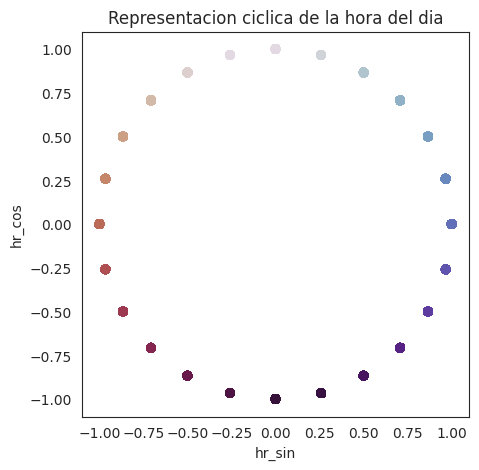

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_train["hr_sin"], X_train["hr_cos"], c=X_train["hr"], cmap="twilight")
ax.set_xlabel("hr_sin")
ax.set_ylabel("hr_cos")
ax.set_title("Representacion ciclica de la hora del dia")
plt.show()


> **Importante:** Después de la transformación, una variable cíclica (como `hr` o `mnth`) pasa a representarse mediante **dos variables** (`sin` y `cos`). Aunque aumenta el número de columnas, **no se agrega información nueva**: simplemente se representa la misma información en un sistema de coordenadas circular, permitiendo que el modelo capture correctamente la naturaleza cíclica de la variable. En la práctica, normalmente se eliminan las variables originales y se utilizan únicamente sus versiones transformadas.

## Paso final: entrenar el modelo con las tecnicas aplicadas

Ya tenemos las columnas nuevas de Winsorization, Target Encoding y variables ciclicas. Ahora armamos la lista final de features para este modelo, reemplazando las columnas originales `windspeed`, `hum`, `hr` y `mnth` por sus versiones transformadas.

Como acordamos en la Tecnica 1, entrenamos sobre `y_train` en su escala original (sin log-transform), para poder aislar el efecto de estas 3 tecnicas y comparar de forma directa contra el baseline de la sesion 1.


In [ ]:
features_finales = [
    "season", "yr", "holiday", "weekday", "workingday", "weathersit",
    "temp", "atemp",
    "windspeed_wins", "windspeed_outlier",
    "hum_wins", "hum_outlier",
    "hr_target_enc",
    "hr_sin", "hr_cos",
    "mnth_sin", "mnth_cos"
]

X_train_fe = X_train[features_finales]
X_test_fe = X_test[features_finales]

X_train_fe.head()


,season,yr,holiday,weekday,workingday,weathersit,temp,atemp,windspeed_wins,windspeed_outlier,hum_wins,hum_outlier,hr_target_enc,hr_sin,hr_cos,mnth_sin,mnth_cos
17440,1,1,0,5,1,1,0.30,0.3030,0.1343,0,0.49,0,312.100520,-0.866025,-0.500000,-0.500000,0.866025
16867,4,1,0,2,1,1,0.48,0.4697,0.2239,0,0.67,0,309.410562,-0.965926,0.258819,-0.500000,0.866025
14851,3,1,0,1,1,1,0.62,0.6212,0.2985,0,0.38,0,309.410562,-0.965926,0.258819,-0.866025,-0.500000
5446,3,0,0,1,1,1,0.66,0.6212,0.2537,0,0.69,0,130.043706,-0.500000,0.866025,-0.500000,-0.866025
6025,3,0,0,5,1,2,0.62,0.5152,0.1642,0,0.93,1,32.613636,0.258819,0.965926,-0.866025,-0.500000


In [ ]:
modelo_lr = LinearRegression()  # Crea el modelo de Regresión Lineal

modelo_lr.fit(X_train_fe, y_train) # Entrena el modelo utilizando el train set

LinearRegression()

Generamos las predicciones sobre el conjunto de prueba y calculamos RMSE y R2, para compararlas directamente contra el baseline de la sesion 1.


In [ ]:
# Genera las predicciones sobre el test set
y_pred_lr = modelo_lr.predict(X_test_fe)

# Calcula las métricas de desempeño
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# Muestra los resultados para compararlos con el baseline de la sesión 1
print(f"RMSE: {rmse_lr:.2f}")
print(f"R²: {r2_lr:.3f}")

RMSE: 99.97
R²: 0.680


## Comparacion rapida contra el baseline

Recordemos los numeros del baseline de la sesion 1, y comparemoslos contra este nuevo modelo.


In [ ]:
resultados_fe = {
    "modelo": "Con feature engineering (winsorization, target encoding, ciclicas)",
    "rmse": rmse_lr,
    "r2": r2_lr
}

comparacion = pd.DataFrame([
    {"modelo": "Baseline (sesion 1)", "rmse": 136.319, "r2": 0.405},
    resultados_fe
])

comparacion


,modelo,rmse,r2
0,Baseline (sesion 1),136.319000,0.405000
1,"Con feature engineering (winsorization, target...",99.972445,0.679914


### Conclusion

Es muy probable posible que el RMSE disminuya y el R² aumente respecto al baseline. Esto se debe a que la **Regresión Lineal** depende en gran medida de cómo estén representadas las variables de entrada.

Las técnicas de **feature engineering** aplicadas en esta sesión buscan precisamente facilitar el trabajo del modelo:

- **Winsorización:** reduce la influencia de los valores atípicos, que pueden afectar la estimación de los coeficientes.
- **Variables cíclicas:** permiten representar correctamente relaciones periódicas, como las horas del día o los meses del año.
- **Target Encoding:** resume la información de variables categóricas en una forma que el modelo puede aprovechar más fácilmente.

Es importante recordar que **ninguna de estas técnicas garantiza una mejora**. Su impacto depende del conjunto de datos y del modelo utilizado. Parte del trabajo de un científico de datos consiste en evaluar experimentalmente si una transformación realmente aporta valor, en lugar de asumir que siempre mejorará el desempeño.

### Importancia de las variables

Como ultimo paso, revisemos que variables el modelo considero mas importantes. Esto nos puede dar pistas de que tecnicas de feature engineering aportaron mas valor.


La **Permutation Importance** permite estimar la importancia de cada variable en cualquier modelo predictivo. La idea consiste en **mezclar aleatoriamente los valores de una variable** y medir cuánto empeora el desempeño del modelo. Si el error aumenta considerablemente, significa que esa variable era importante para realizar buenas predicciones. Esta técnica es independiente del algoritmo utilizado y permite comparar la contribución de las variables de forma consistente.

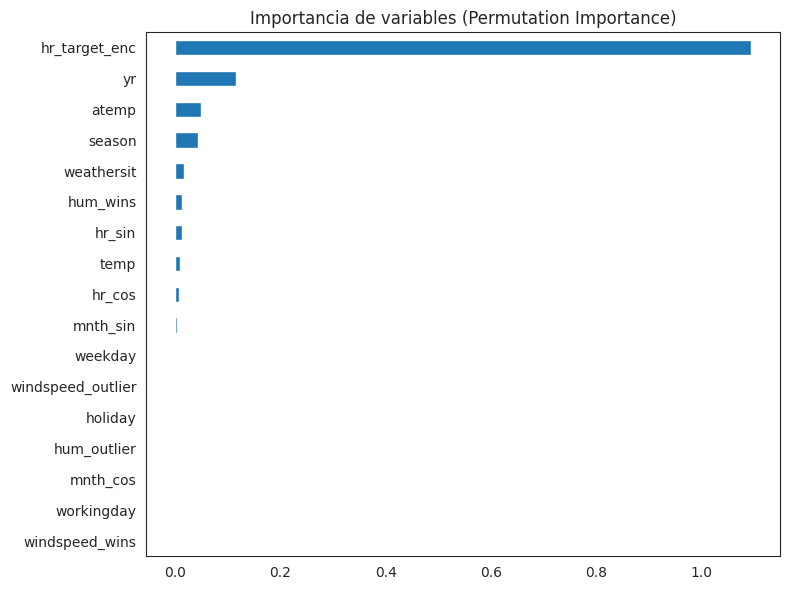

In [ ]:
from sklearn.inspection import permutation_importance

resultado = permutation_importance(
    modelo_lr,
    X_test_fe,
    y_test,
    n_repeats=10,      # Repite el proceso 10 veces para obtener una estimación más estable
    random_state=42    # Fija la semilla para obtener resultados reproducibles
)

# Crea una Serie con la importancia promedio de cada variable
importancias = pd.Series(
    resultado.importances_mean,
    index=features_finales
).sort_values(ascending=False)  # Ordena de mayor a menor importancia

# Grafica la importancia de las variables
fig, ax = plt.subplots(figsize=(8, 6))
importancias.plot(kind="barh", ax=ax)

# Invierte el eje Y para que la variable más importante aparezca arriba
ax.invert_yaxis()

ax.set_title("Importancia de variables (Permutation Importance)")
plt.tight_layout()
plt.show()

## Al final, conviene transformar el target con logaritmo?

#### Comparación entre el target original y el target transformado

Una forma objetiva de evaluar si conviene aplicar una transformación logarítmica al target es entrenar **dos modelos idénticos**: uno utilizando el target original y otro utilizando $\log(1+y)$. En ambos casos, las predicciones se evalúan sobre la **escala original del target**, ya que es la métrica que realmente nos interesa optimizar. Si el modelo entrenado con el target transformado obtiene un menor RMSE y un mayor $R^2$, entonces la transformación resultó beneficiosa para este problema.

In [ ]:

# ============================
# Modelo con el target original
# ============================

# Entrena el modelo utilizando el target en su escala original
modelo_original = LinearRegression()
modelo_original.fit(X_train_fe, y_train)

# Genera las predicciones sobre el conjunto de prueba
y_pred_original = modelo_original.predict(X_test_fe)

# Calcula las métricas de desempeño
rmse_original = np.sqrt(mean_squared_error(y_test, y_pred_original))
r2_original = r2_score(y_test, y_pred_original)


# =====================================
# Modelo con el target transformado (log)
# =====================================

# Aplica la transformación logarítmica al target de entrenamiento
y_train_log = np.log1p(y_train)

# Entrena el modelo sobre el target transformado
modelo_log = LinearRegression()
modelo_log.fit(X_train_fe, y_train_log)

# Genera las predicciones en escala logarítmica
y_pred_log = modelo_log.predict(X_test_fe)

# Convierte las predicciones nuevamente a la escala original
y_pred_log = np.expm1(y_pred_log)

# Calcula las métricas sobre la escala original del target
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2_log = r2_score(y_test, y_pred_log)

In [ ]:
# Resumen de resultados
resultados = pd.DataFrame({
    "Modelo": ["Target original", "Target log1p"],
    "RMSE": [rmse_original, rmse_log],
    "R²": [r2_original, r2_log]
})

resultados

,Modelo,RMSE,R²
0,Target original,99.972445,0.679914
1,Target log1p,155.659756,0.224005


Recordemos que el modelo optimiza el objetivo que recibe durante el entrenamiento, **no necesariamente la métrica que nos interesa al final**. Por eso, una transformación logarítmica puede mejorar o empeorar el RMSE y el R² dependiendo del conjunto de datos y del modelo utilizado.